In [3]:
#Q1. Load and visualize AirPassengers dataset

import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

data = pd.read_csv(url)

data.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


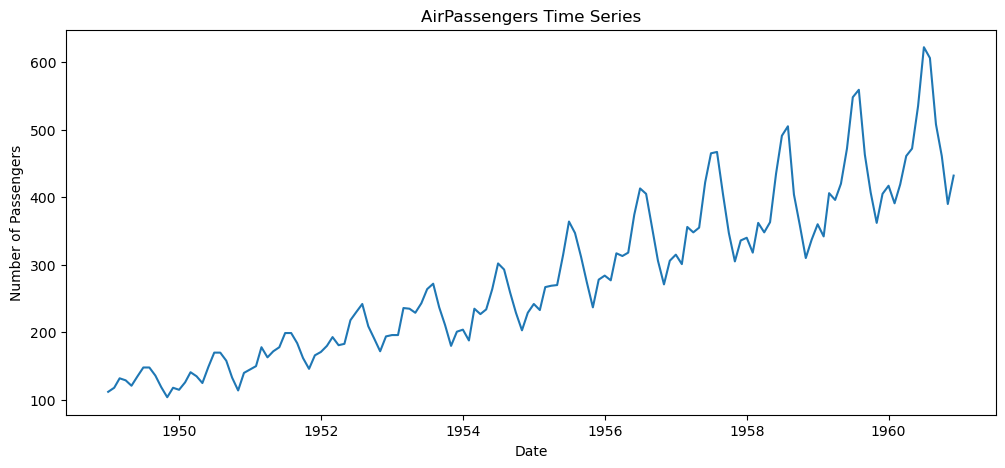

In [4]:
data["Month"] = pd.to_datetime(data["Month"])

data.set_index("Month", inplace=True)

plt.figure(figsize=(12, 5))
plt.plot(data["Passengers"])
plt.title("AirPassengers Time Series")
plt.xlabel("Date")
plt.ylabel("Number of Passengers")
plt.show()

In [5]:
#Q2. Missing values and summary statistics
print("Missing Values:")
print(data.isnull().sum())

print("\nSummary Statistics:")
print(data.describe())

Missing Values:
Passengers    0
dtype: int64

Summary Statistics:
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


<Figure size 1500x1000 with 0 Axes>

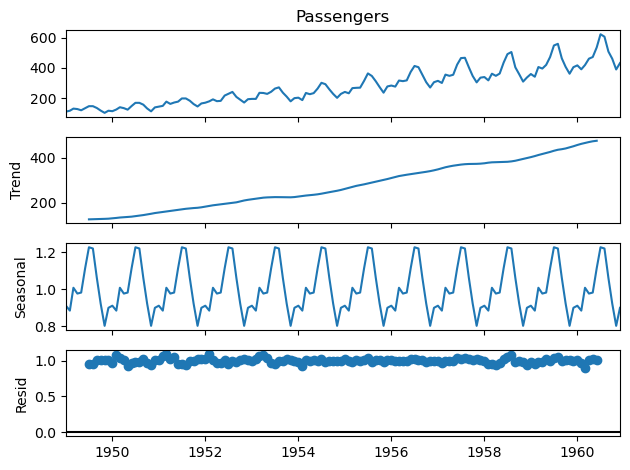

In [6]:
# Q3. Decompose the time series

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    data["Passengers"],
    model="multiplicative",
    period=12
)

plt.figure(figsize=(15, 10))
result.plot()
plt.show()

In [7]:
#Q4. Augmented Dickey-Fuller Test

from statsmodels.tsa.stattools import adfuller

result = adfuller(data["Passengers"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")

ADF Statistic: 0.8153688792060435
p-value: 0.9918802434376409
The time series is not stationary.


In [8]:
#Q5. 80% Train and 20% Test split

training_size = int(len(data) * 0.80)

train = data.iloc[:training_size]
test = data.iloc[training_size:]

print("Total data:", len(data))
print("Training data:", len(train))
print("Testing data:", len(test))

Total data: 144
Training data: 115
Testing data: 29
